#### A.Extract ‘plant-seedlings-classification.zip’ into new folder (unzipped) using python.

In [5]:
import zipfile
from zipfile import ZipFile
import os



# ZIP file path
zip_file = r"D:\back up docs\AIML course\Projects\Project 9\plant-seedlings-classification.zip"
extract_path = r"D:\back up docs\AIML course\Projects\Project 9\unzipped_plant"


# Create output folder
os.makedirs(extract_path, exist_ok=True)

# Extract contents
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"Files extracted successfully to '{extract_path}'")


Files extracted successfully to 'D:\back up docs\AIML course\Projects\Project 9\unzipped_plant'


#### B.Map the images from train folder with train labels to form a DataFrame.

In [10]:
import cv2
import pandas as pd

train_dir = r"D:\back up docs\AIML course\Projects\Project 9\unzipped_plant\plant-seedlings-classification\train"
data = []

for species in os.listdir(train_dir):
    species_path = os.path.join(train_dir, species)

    if os.path.isdir(species_path):

        for img_name in os.listdir(species_path):

            img_path = os.path.join(species_path, img_name)

            # Read image
            image = cv2.imread(img_path)

            # Append data
            data.append([img_name, species, image])

# Create DataFrame
df = pd.DataFrame(
    data,
    columns=["Image_Name", "Species", "Actual_Image"]
)

print(df.head())
print("Total Images:", len(df))

      Image_Name      Species  \
0  0050f38b3.png  Black-grass   
1  0183fdf68.png  Black-grass   
2  0260cffa8.png  Black-grass   
3  05eedce4d.png  Black-grass   
4  075d004bc.png  Black-grass   

                                        Actual_Image  
0  [[[27, 50, 80], [18, 42, 71], [36, 57, 83], [4...  
1  [[[37, 43, 55], [37, 43, 54], [40, 46, 57], [4...  
2  [[[24, 32, 45], [21, 30, 44], [22, 30, 45], [2...  
3  [[[51, 84, 108], [56, 89, 112], [54, 88, 110],...  
4  [[[165, 162, 162], [165, 161, 163], [160, 157,...  
Total Images: 4750


#### Write a function that will select n random images and display images along with its species.
###### Hint: If input for function is 5, it should print 5 random images along with its labels

In [19]:
import random
import matplotlib.pyplot as plt
import cv2

def display_random_images(n):
    
    # Select n random rows from DataFrame
    random_rows = df.sample(n=n)

    for a, row in random_rows.iterrows():

        image = row['Actual_Image']
        species = row['Species']

        # Convert BGR to RGB for correct display
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(2,2))
        plt.imshow(image_rgb)
        plt.title(f"Species: {species}")
        plt.axis('off')
        plt.show()

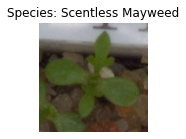

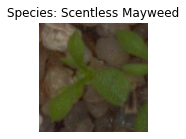

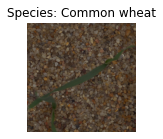

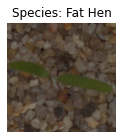

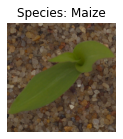

In [20]:
display_random_images(5)

In [21]:
# Features (images)
X = df['Actual_Image']

# Target labels (species)
Y = df['Species']

print("X Shape:", X.shape)
print("Y Shape:", Y.shape)

X Shape: (4750,)
Y Shape: (4750,)


#### B. Encode labels of the images. 

In [27]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
label_encoder = LabelEncoder()

# Encode species labels
Y_encoded = label_encoder.fit_transform(Y)

print(Y_encoded[:10])

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "->", class_name)

[0 0 0 0 0 0 0 0 0 0]
0 -> Black-grass
1 -> Charlock
2 -> Cleavers
3 -> Common Chickweed
4 -> Common wheat
5 -> Fat Hen
6 -> Loose Silky-bent
7 -> Maize
8 -> Scentless Mayweed
9 -> Shepherds Purse
10 -> Small-flowered Cranesbill
11 -> Sugar beet


In [28]:
X = df['Actual_Image'].values
Y = df['Species'].values

label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)

#### C. Unify shape of all the images.

In [30]:
import numpy as np

IMG_SIZE = 128

X_resized = []

for image in X:
    resized_image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    X_resized.append(resized_image)

X_resized = np.array(X_resized)

print(X_resized.shape)

(4750, 128, 128, 3)


In [33]:
# Normalize images
X_normalized = X_resized.astype('float32') / 255.0

print(X_normalized.shape)
print(X_normalized.min())
print(X_normalized.max())
X = df['Actual_Image'].values
Y = df['Species'].values

# Encode labels
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

# Resize images
X_resized = np.array([
    cv2.resize(img, (128, 128))
    for img in X])

# Normalize images
X_normalized = X_resized.astype('float32') / 255.0

(4750, 128, 128, 3)
0.0
1.0


#### A. Split the data into train and test data. 


In [35]:
from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(
    X_normalized,
    Y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=Y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3800, 128, 128, 3)
Testing data shape: (950, 128, 128, 3)


#### Create new CNN architecture to train the model. 

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (12 plant species)
model.add(Dense(12, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 14, 14, 128)      0

#### Train the model on train data and validate on test data.

In [40]:

history = model.fit(
    X_train,
    Y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, Y_test))

Epoch 1/20
119/119 [==============================] - 42s 354ms/step - loss: 0.7480 - accuracy: 0.7261 - val_loss: 0.7517 - val_accuracy: 0.7589
Epoch 2/20
119/119 [==============================] - 39s 327ms/step - loss: 0.6907 - accuracy: 0.7458 - val_loss: 0.7708 - val_accuracy: 0.7600
Epoch 3/20
119/119 [==============================] - 42s 352ms/step - loss: 0.6630 - accuracy: 0.7579 - val_loss: 0.7279 - val_accuracy: 0.7779
Epoch 4/20
119/119 [==============================] - 40s 332ms/step - loss: 0.6491 - accuracy: 0.7576 - val_loss: 0.7198 - val_accuracy: 0.7811
Epoch 5/20
119/119 [==============================] - 40s 334ms/step - loss: 0.5697 - accuracy: 0.7911 - val_loss: 0.8215 - val_accuracy: 0.7537
Epoch 6/20
119/119 [==============================] - 40s 336ms/step - loss: 0.5797 - accuracy: 0.7897 - val_loss: 0.7495 - val_accuracy: 0.7811
Epoch 7/20
119/119 [==============================] - 40s 340ms/step - loss: 0.5706 - accuracy: 0.7926 - val_loss: 0.7506 - val_ac

In [41]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.871842086315155
Final Validation Accuracy: 0.7905263304710388


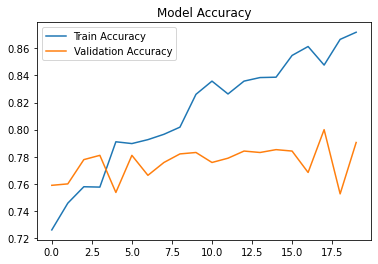

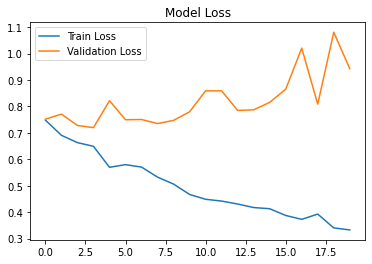

In [42]:
# Plotting the accuracy and loss

import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')
plt.show()

#### Select a random image and print actual label and predicted label for the same

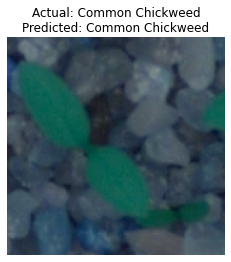

Actual Label    : Common Chickweed
Predicted Label : Common Chickweed


In [47]:
# Select a random test image
idx = random.randint(0, len(X_test) - 1)

# Image and actual label
image = X_test[idx]
actual_label = Y_test[idx]

# Predict
prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)
predicted_label = np.argmax(prediction)

# Convert encoded labels back to species names
actual_species = label_encoder.inverse_transform([actual_label])[0]
predicted_species = label_encoder.inverse_transform([predicted_label])[0]

# Display image
plt.imshow(image)
plt.title(f"Actual: {actual_species}\nPredicted: {predicted_species}")
plt.axis('off')
plt.show()

# Print labels
print("Actual Label    :", actual_species)
print("Predicted Label :", predicted_species)

#### DOMAIN: Botanical Resea 
• CONTEXT: University X is currently undergoing some research involving understanding the characteristics of flowers. They already have invested on curating sample images. They require an automation which can create a classifier capable of determining a flower’s species from a photo.

• DATA DESCRIPTION: The dataset comprises of images from 17 plant species.

• PROJECT OBJECTIVE: To experiment with various approaches to train an image classifier to predict type of flower from the image.

##### Import and read oxflower17 dataset from tflearn and split into X and Y while loading

In [27]:
from tflearn.datasets import oxflower17
import numpy as np
import cv2

X, y = oxflower17.load_data()

print("Images:", len(X))
print("Labels:", len(y))

Images: 1360
Labels: 1360


#### Print Number of images and shape of the images

In [7]:
print("Number of images:", len(X))
print("Shape of dataset:", np.array(X).shape)
print("Shape of one image:", np.array(X[0]).shape)

Number of images: 1360
Shape of dataset: (1360, 224, 224, 3)
Shape of one image: (224, 224, 3)


##### Print count of each class from y.

In [8]:
from collections import Counter

class_count = Counter(y)

for label, count in sorted(class_count.items()):
    print(f"Class {label}: {count} images")

Class 0: 80 images
Class 1: 80 images
Class 2: 80 images
Class 3: 80 images
Class 4: 80 images
Class 5: 80 images
Class 6: 80 images
Class 7: 80 images
Class 8: 80 images
Class 9: 80 images
Class 10: 80 images
Class 11: 80 images
Class 12: 80 images
Class 13: 80 images
Class 14: 80 images
Class 15: 80 images
Class 16: 80 images


##### Display 5 random images. 

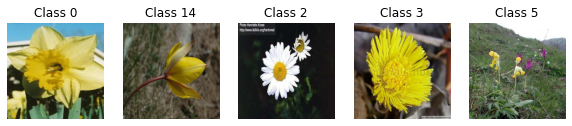

In [20]:
import matplotlib.pyplot as plt
import random
plt.figure(figsize=(10, 5))

for i in range(5):
    idx = random.randint(0, len(X)-1)

    plt.subplot(1, 5, i+1)
    plt.imshow(X[idx])
    plt.title(f"Class {y[idx]}")
    plt.axis('off')

plt.show()

#### Select any image from the dataset and assign it to a variable.

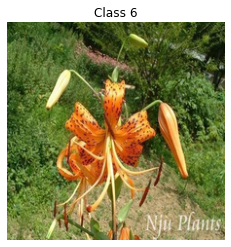

In [22]:
img = X[14]

plt.imshow(img)
plt.title(f"Class {y[0]}")
plt.axis('off')
plt.show()

#### Transform the image into grayscale format and display the same. 

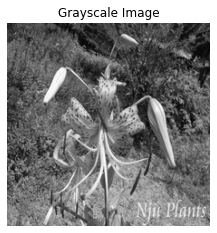

In [44]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')

plt.show()

#### Apply a filter to sharpen the image and display the image before and after sharpening. [

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


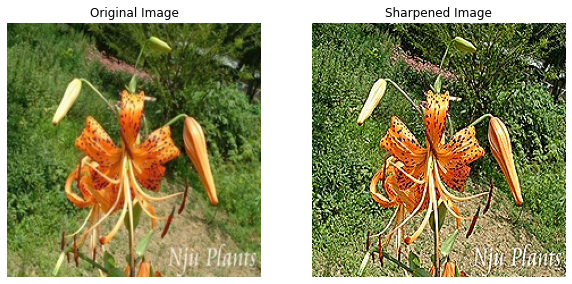

In [41]:
kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

sharpened_img = cv2.filter2D(img, -1, kernel)
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sharpened_img)
plt.title("Sharpened Image")
plt.axis('off')

plt.show()

#### Apply a filter to blur the image and display the image before and after blur.

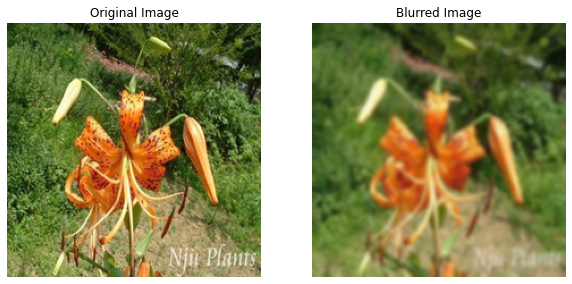

In [42]:

# Apply Gaussian Blur
blurred_img = cv2.GaussianBlur(img, (9, 9), 0)

# Display Original and Blurred Images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blurred_img)
plt.title("Blurred Image")
plt.axis('off')

plt.show()

##### Display all the 4 images from above questions besides each other to observe the difference

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


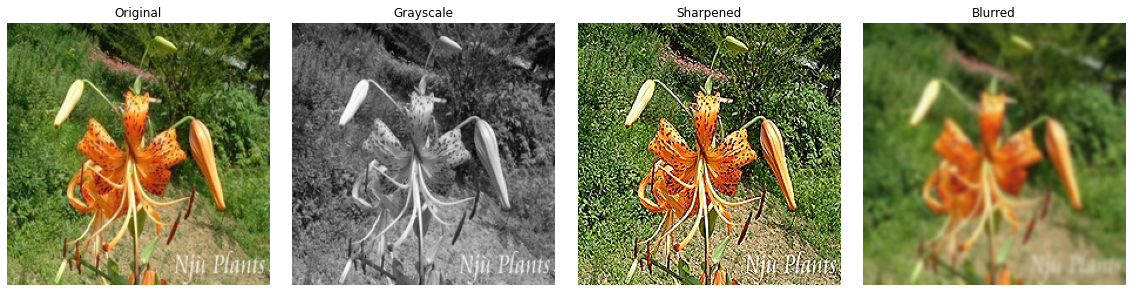

In [43]:
# Display all images together
plt.figure(figsize=(16, 4))

# Original
plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

# Grayscale
plt.subplot(1, 4, 2)
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

# Sharpened
plt.subplot(1, 4, 3)
plt.imshow(sharpened_img)
plt.title("Sharpened")
plt.axis('off')

# Blurred
plt.subplot(1, 4, 4)
plt.imshow(blurred_img)
plt.title("Blurred")
plt.axis('off')

plt.tight_layout()
plt.show()

##### Split the data into train and test with 80:20 proportion

In [45]:
from sklearn.model_selection import train_test_split
import numpy as np

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# For ML models, flatten images
X_flat = X.reshape(len(X), -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1088
Testing samples: 272


#### Train a model using any Supervised Learning algorithm and share performance metrics on test data.

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.4742647058823529
              precision    recall  f1-score   support

           0       0.58      0.44      0.50        16
           1       0.36      0.25      0.30        16
           2       0.65      0.69      0.67        16
           3       0.44      0.25      0.32        16
           4       0.52      0.69      0.59        16
           5       0.11      0.19      0.14        16
           6       0.50      0.56      0.53        16
           7       0.53      0.56      0.55        16
           8       0.62      0.62      0.62        16
           9       0.43      0.38      0.40        16
          10       0.56      0.56      0.56        16
          11       0.42      0.50      0.46        16
          12       0.59      0.62      0.61        16
          13       0.60      0.38      0.46        16
          14       0.08      0.06      0.07        16
          15       0.47      0.44      0.45        16
          16       0.74      0.88      0.80        1

#### Train a model using Neural Network and share performance metrics on test data.

In [47]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))

[[ 7  0  0  1  1  1  1  0  0  2  1  0  0  0  1  1  0]
 [ 0  4  1  0  0  1  0  0  2  1  2  2  0  0  1  1  1]
 [ 0  1 11  0  0  0  0  3  0  0  0  0  0  1  0  0  0]
 [ 1  0  0  4  2  2  1  0  1  0  0  0  0  0  2  1  2]
 [ 0  0  0  1 11  1  3  0  0  0  0  0  0  0  0  0  0]
 [ 1  0  0  0  1  3  1  0  0  1  0  0  2  2  4  1  0]
 [ 0  0  0  1  2  2  9  1  0  0  0  0  0  0  1  0  0]
 [ 0  1  3  0  0  1  0  9  2  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  2  0  2 10  0  0  0  0  0  1  0  0]
 [ 0  2  0  0  0  2  0  0  0  6  1  2  1  0  0  2  0]
 [ 0  1  0  0  0  2  0  0  0  2  9  2  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  1  1  0  1  8  3  0  0  1  0]
 [ 0  1  0  0  0  1  1  0  0  0  0  2 10  1  0  0  0]
 [ 1  0  0  0  0  4  0  0  0  0  1  0  1  6  0  1  2]
 [ 2  0  0  1  4  4  2  0  0  1  0  1  0  0  1  0  0]
 [ 0  1  0  0  0  1  0  1  0  1  1  2  0  0  2  7  0]
 [ 0  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0 14]]


In [48]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=50,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Accuracy: 0.07720588235294118
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.00      0.00      0.00        16
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00        16
           4       0.00      0.00      0.00        16
           5       0.00      0.00      0.00        16
           6       0.17      0.12      0.14        16
           7       0.00      0.00      0.00        16
           8       0.00      0.00      0.00        16
           9       0.00      0.00      0.00        16
          10       0.00      0.00      0.00        16
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        16
          13       0.15      0.44      0.22        16
          14       0.06      0.75      0.11        16
          15       0.00      0.00      0.00        16
          16       0.00      0.00      0.00        

C:\Users\Helios 300\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:702: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Helios 300\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Helios 300\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\Helios 300\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision a

##### Train a model using a basic CNN and share performance metrics on test data. 

In [50]:
from sklearn.model_selection import train_test_split

X = np.array(X) / 255.0
y = np.array(y)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

cnn = Sequential()

cnn.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(224,224,3)
))

cnn.add(MaxPooling2D((2,2)))

cnn.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

cnn.add(MaxPooling2D((2,2)))

cnn.add(Flatten())

cnn.add(Dense(
    128,
    activation='relu'
))

cnn.add(Dense(
    17,
    activation='softmax'
))

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=10,
    validation_data=(X_test_cnn,y_test_cnn)
)

Train on 1088 samples, validate on 272 samples
Epoch 1/10
1088/1088 [==============================] - ETA: 0s - loss: 2.8346 - acc: 0.0478

C:\Users\Helios 300\anaconda3\lib\site-packages\keras\engine\training_v1.py:2332: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates


1088/1088 [==============================] - 36s 33ms/sample - loss: 2.8346 - acc: 0.0478 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 2/10
1088/1088 [==============================] - 31s 29ms/sample - loss: 2.8337 - acc: 0.0469 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 3/10
1088/1088 [==============================] - 31s 28ms/sample - loss: 2.8335 - acc: 0.0460 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 4/10
1088/1088 [==============================] - 31s 29ms/sample - loss: 2.8335 - acc: 0.0506 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 5/10
1088/1088 [==============================] - 31s 28ms/sample - loss: 2.8335 - acc: 0.0487 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 6/10
1088/1088 [==============================] - 31s 28ms/sample - loss: 2.8335 - acc: 0.0496 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 7/10
1088/1088 [==============================] - 33s 30ms/sample - loss: 2.8335 - acc: 0.0607 - val_loss: 2.8332 - val_acc: 0.0588
Epoch 8/10
1088/1088 [=======================

In [52]:
loss, accuracy = cnn.evaluate(
    X_test_cnn,
    y_test_cnn
)

print("CNN Accuracy:", accuracy)

CNN Accuracy: 0.05882353


#### Predict the class/label of image ‘Prediction.jpg’ using best performing model and share predicted label.

In [60]:
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("MLP Accuracy:",
      accuracy_score(y_test, y_pred_mlp))

print("CNN Accuracy:",accuracy)

Random Forest Accuracy: 0.4742647058823529
MLP Accuracy: 0.07720588235294118
CNN Accuracy: 0.05882353


In [68]:
import cv2
import numpy as np

# Read image
img = cv2.imread(r"D:\back up docs\AIML course\Projects\Project 9\Prediction-img.jpg")

# Convert color
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

# Resize to match dataset image size
img = cv2.resize(img, (224, 224))

# Normalize
img = img / 255.0

# Flatten image because Random Forest was trained on flattened images
img_flat = img.reshape(1, -1)

# Predict
predicted_label = rf.predict(img_flat)

print("Predicted Label:", predicted_label[0])

Predicted Label: 2


In [69]:
flower_classes = {
    0: "Daffodil",
    1: "Snowdrop",
    2: "Lily Valley",
    # ...
    16: "Tulip"
}

print("Predicted Flower:",
      flower_classes[predicted_label[0]])


Predicted Flower: Lily Valley
